In [ ]:
import os
import cv2
import json
import numpy as np
import pandas as pd
from tqdm import tqdm

import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
sns.set_context("talk")




In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!ls /content/drive/MyDrive/


 11_6_2025
'12.1.ÔN TẬP KIỂM TRA HỌC KÌ I LỚP 12.pdf'
'12.2. ĐỀ ÔN HKI SỐ 02-lớp.pdf'
'12.2.ĐỀ ÔN  HỌC KÌ I SỐ 02.pdf'
'12.3.Ä'$'\302\220''EÌ‚Ì€-OÌ‚N-HKI-SOÌ‚Ì'$'\302\201''-03.pdf'
'12.3.ĐỀ ÔN HKI SỐ 03-LỚP.docx'
'12.3. ĐỀ ÔN HKI SỐ 03-LỚP.pdf'
'12A1 Quang Khải Minh Khoa'
 1e9c1425ebd95a4fa29e6dac3cae0050_8610e4f1f07e46bf841791e7184f21311639235438.docx
 268125379_4693218417412411_1813161363966319495_n.jpg
 269024855_660791094946504_1729466368055306608_n.gif
'Ä'$'\302\220''á»€-Ã”N-THI-Há»ŒC-Ká»²-1-Ä'$'\302\220''á»€-1.pdf'
'Ai da dat ten cho dong song trich.pdf'
'Ảnh sảnh chính ĐH FPT '
'Bài 11 Liên kết gen và hoán vị gen.docx'
'Bảng tính chưa có tiêu đề.gsheet'
'Bản sao của [BEC] CAM KẾT KHÓA HỌC  (1).docx'
'Bản sao của [BEC] CAM KẾT KHÓA HỌC  (2).docx'
'Bản sao của [BEC] CAM KẾT KHÓA HỌC  (3).docx'
'Bản sao của [BEC] CAM KẾT KHÓA HỌC  (4).docx'
'Bản sao của [BEC] CAM KẾT KHÓA HỌC  (5).docx

In [ ]:
import os

BASE_DIR = "/content/drive/MyDrive/colab_project"
DATA_DIR = f"{BASE_DIR}/data"
ZIP_DIR  = f"{DATA_DIR}/zips"
MERGE_DIR = f"{BASE_DIR}/output"

for d in [DATA_DIR, ZIP_DIR, MERGE_DIR]:
    os.makedirs(d, exist_ok=True)

print("✅ Đã tạo xong cấu trúc thư mục")


✅ Đã tạo xong cấu trúc thư mục


In [ ]:
# import gdown
# import zipfile

# FILES = {
#     "flir": "1quWNzPZyYEJ0kPQrq3O43J0_WPCuUyH3",
#     "Kaist": "1WDN3zo63uijySECsVIRkBW3CjQtlCWC-"
# }

# def download_and_unzip(name, file_id):
#     zip_path = f"{ZIP_DIR}/{name}.zip"
#     extract_path = f"{DATA_DIR}/{name}"

#     # Download
#     if not os.path.exists(zip_path):
#         print(f"⬇️ Đang tải {name}...")
#         url = f"https://drive.google.com/uc?id={file_id}"
#         gdown.download(url, zip_path, quiet=False)
#     else:
#         print(f"✅ {name}.zip đã tồn tại, bỏ qua tải")

#     # Unzip
#     if not os.path.exists(extract_path):
#         print(f"📦 Giải nén {name}...")
#         with zipfile.ZipFile(zip_path, 'r') as zip_ref:
#             zip_ref.extractall(extract_path)
#     else:
#         print(f"✅ {name} đã được giải nén")

# for name, fid in FILES.items():
#     download_and_unzip(name, fid)


In [ ]:
def build_flir_metadata(root_dir, split="train"):
    ann_path = os.path.join(root_dir, split, "thermal_annotations.json")

    with open(ann_path, "r") as f:
        coco = json.load(f)

    images = {img["id"]: img for img in coco["images"]}
    anns = coco["annotations"]

    records = []

    for img_id, img in images.items():
        img_anns = [a for a in anns if a["image_id"] == img_id and a["category_id"] == 1]  # person=1

        bboxes = [a["bbox"] for a in img_anns]
        areas = [b[2] * b[3] for b in bboxes]

        records.append({
            "dataset": "FLIR",
            "split": split,
            "image_id": img_id,
            "rgb_path": os.path.join(root_dir, split, "RGB", img["file_name"]),
            "thermal_path": os.path.join(root_dir, split, "thermal_8_bit", img["file_name"]),
            "num_person": len(bboxes),
            "avg_bbox_area": np.mean(areas) if areas else 0
        })

    return pd.DataFrame(records)


In [ ]:
def build_kaist_metadata(root_dir):
    records = []

    for set_name in sorted(os.listdir(root_dir)):
        if not set_name.startswith("set"):
            continue

        set_path = os.path.join(root_dir, set_name)

        for video in os.listdir(set_path):
            video_path = os.path.join(set_path, video)

            rgb_dir = os.path.join(video_path, "visible")
            thermal_dir = os.path.join(video_path, "lwir")

            if not os.path.exists(rgb_dir) or not os.path.exists(thermal_dir):
                continue

            for img_name in sorted(os.listdir(rgb_dir)):
                rgb_path = os.path.join(rgb_dir, img_name)
                thermal_path = os.path.join(thermal_dir, img_name)

                if not os.path.exists(thermal_path):
                    continue

                records.append({
                    "dataset": "KAIST",
                    "rgb_path": rgb_path,
                    "thermal_path": thermal_path,
                    "num_person": np.nan,
                    "avg_bbox_area": np.nan
                })

    return pd.DataFrame(records)


In [ ]:
# CHANGE PATH
FLIR_ROOT = "/content/drive/MyDrive/colab_project/data/flir/FLIR_ADAS_1_3"
KAIST_ROOT = "/content/drive/MyDrive/colab_project/data/Kaist"

df_flir = build_flir_metadata(FLIR_ROOT, split="train")
df_kaist = build_kaist_metadata(KAIST_ROOT)

df_all = pd.concat([df_flir, df_kaist], ignore_index=True)

print("FLIR:", df_flir.shape)
print("KAIST:", df_kaist.shape)
print("TOTAL:", df_all.shape)

df_all.head()


FLIR: (8862, 7)
KAIST: (47264, 5)
TOTAL: (56126, 7)


,dataset,split,image_id,rgb_path,thermal_path,num_person,avg_bbox_area
0,FLIR,train,0.0,/content/drive/MyDrive/colab_project/data/flir...,/content/drive/MyDrive/colab_project/data/flir...,0.0,0.0
1,FLIR,train,1.0,/content/drive/MyDrive/colab_project/data/flir...,/content/drive/MyDrive/colab_project/data/flir...,0.0,0.0
2,FLIR,train,2.0,/content/drive/MyDrive/colab_project/data/flir...,/content/drive/MyDrive/colab_project/data/flir...,0.0,0.0
3,FLIR,train,3.0,/content/drive/MyDrive/colab_project/data/flir...,/content/drive/MyDrive/colab_project/data/flir...,1.0,260.0
4,FLIR,train,4.0,/content/drive/MyDrive/colab_project/data/flir...,/content/drive/MyDrive/colab_project/data/flir...,0.0,0.0


In [ ]:
df_all.groupby("dataset").size()

,0
dataset,
FLIR,8862
KAIST,47264


In [ ]:
df_all.isna().mean()

,0
dataset,0.000000
split,0.842105
image_id,0.842105
rgb_path,0.000000
thermal_path,0.000000
num_person,0.842105
avg_bbox_area,0.842105


Conclusion

In [ ]:
sample = (
    df_all
    .groupby("dataset", group_keys=False)
    .apply(lambda x: x.sample(
        n=min(400, len(x)),
        random_state=42
    ))
)

/tmp/ipython-input-3890541537.py:4: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x.sample(


In [ ]:
def get_resolution(path):
    img = cv2.imread(path)
    if img is None:
        return None, None
    h, w = img.shape[:2]
    return w, h


In [ ]:


ws, hs = [], []
for p in tqdm(sample["rgb_path"]):
    w, h = get_resolution(p)
    ws.append(w)
    hs.append(h)

sample["width"] = ws
sample["height"] = hs


100%|██████████| 800/800 [08:31<00:00,  1.57it/s]


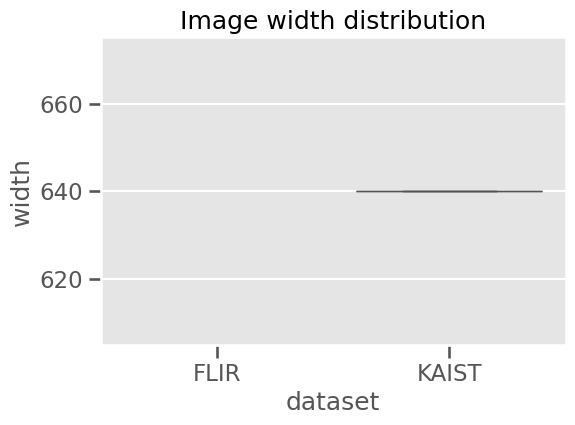

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=sample, x="dataset", y="width")
plt.title("Image width distribution")
plt.show()

Conclusion:

In [ ]:
def thermal_stats(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None, None
    return img.mean(), img.std()


In [ ]:
means, stds = [], []

for p in tqdm(sample["thermal_path"]):
    m, s = thermal_stats(p)
    means.append(m)
    stds.append(s)

sample["thermal_mean"] = means
sample["thermal_std"] = stds


100%|██████████| 800/800 [05:41<00:00,  2.34it/s]


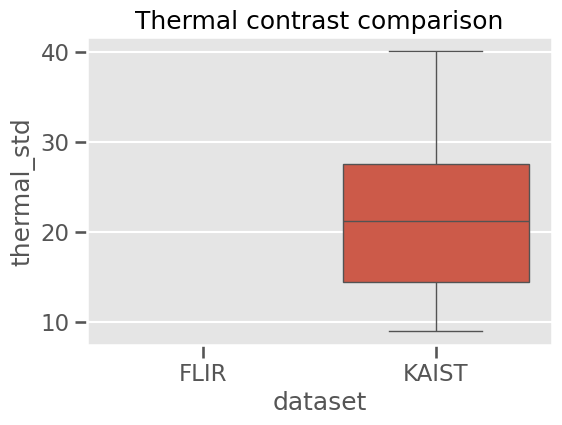

In [ ]:
plt.figure(figsize=(6,4))
sns.boxplot(data=sample, x="dataset", y="thermal_std")
plt.title("Thermal contrast comparison")
plt.show()


Conclusion

In [ ]:
def brightness(path):
    img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    return img.mean()


In [ ]:
sample["rgb_brightness"] = [
    brightness(p) for p in tqdm(sample["rgb_path"])
]

100%|██████████| 800/800 [00:09<00:00, 83.77it/s]


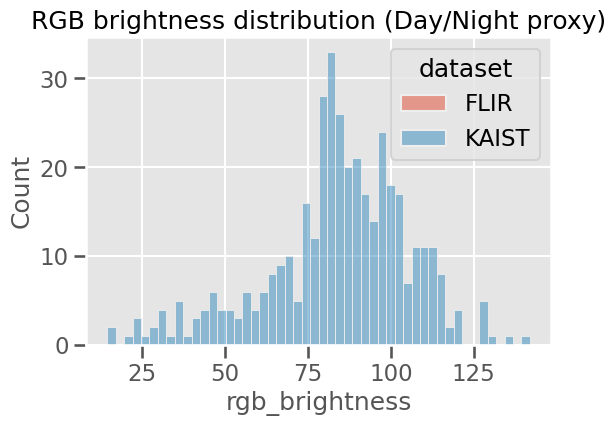

In [ ]:
plt.figure(figsize=(6,4))
sns.histplot(
    data=sample,
    x="rgb_brightness",
    hue="dataset",
    bins=50
)
plt.title("RGB brightness distribution (Day/Night proxy)")
plt.show()


In [ ]:
sample["dataset"].value_counts()

,count
dataset,
FLIR,400
KAIST,400


In [ ]:
print(df_all.columns.tolist())


['dataset', 'split', 'image_id', 'rgb_path', 'thermal_path', 'num_person', 'avg_bbox_area', 'rgb_exists', 'thermal_brightness']


In [ ]:
from PIL import Image
import numpy as np

def fast_rgb_brightness(img_path, size=(64, 64)):
    try:
        img = Image.open(img_path).convert("L")
        img = img.resize(size)
        return float(np.array(img).mean())
    except:
        return np.nan


In [ ]:
import numpy as np
df_all["brightness"] = np.nan

# KAIST → RGB brightness
mask_kaist = df_all["dataset"] == "KAIST"
df_all.loc[mask_kaist, "brightness"] = (
    df_all.loc[mask_kaist, "rgb_path"]
    .apply(fast_rgb_brightness)
)

# FLIR → Thermal brightness
mask_flir = df_all["dataset"] == "FLIR"
df_all.loc[mask_flir, "brightness"] = (
    df_all.loc[mask_flir, "thermal_path"]
    .apply(fast_rgb_brightness)   # same function, different modality
)



NameError: name 'df_all' is not defined

In [ ]:
df_all["modality"] = "Unknown"
df_all.loc[mask_kaist, "modality"] = "RGB"
df_all.loc[mask_flir, "modality"] = "Thermal"


In [ ]:

df_plot = df_all[df_all["brightness"].notna()]


<Axes: xlabel='brightness', ylabel='Count'>

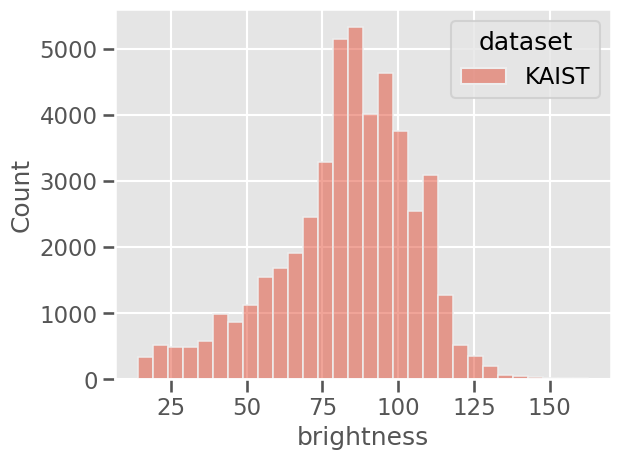

In [ ]:
sns.histplot(
    data=df_plot,
    x="brightness",
    hue="dataset",
    bins=30,
    stat="count",
    common_norm=False
)


In [ ]:
import hashlib

def file_hash(path, block_size=65536):
    try:
        hasher = hashlib.md5()
        with open(path, "rb") as f:
            for block in iter(lambda: f.read(block_size), b""):
                hasher.update(block)
        return hasher.hexdigest()
    except:
        return None


In [ ]:
df_all["rgb_hash"] = df_all["rgb_path"].apply(file_hash)
df_all["thermal_hash"] = df_all["thermal_path"].apply(file_hash)


In [ ]:
df_all.duplicated(subset=["rgb_hash"]).sum()
df_all.duplicated(subset=["thermal_hash"]).sum()


np.int64(8861)

In [ ]:
import cv2
import hashlib
import numpy as np

def fast_image_hash(img_path, size=32):
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        return None
    img = cv2.resize(img, (size, size))
    return hashlib.md5(img.tobytes()).hexdigest()

# chỉ làm cho EDA sample
df_all["rgb_fast_hash"] = df_all["rgb_path"].apply(fast_image_hash)

df_all.duplicated(subset=["rgb_fast_hash"]).sum()



In [ ]:
# ===== EDA: RAW IMAGE STATISTICS (NO NORMALIZATION) =====

import numpy as np
import cv2
from PIL import Image
import pandas as pd

# ---------- RGB METRICS ----------

def rgb_mean_std(img_path, size=(64, 64)):
    try:
        img = Image.open(img_path).convert("RGB").resize(size)
        arr = np.array(img) / 255.0
        mean = arr.mean(axis=(0,1))   # R,G,B
        std  = arr.std(axis=(0,1))
        return mean, std
    except:
        return (np.nan, np.nan, np.nan), (np.nan, np.nan, np.nan)

def rgb_brightness(img_path, size=(64, 64)):
    try:
        img = Image.open(img_path).convert("L").resize(size)
        return float(np.array(img).mean())
    except:
        return np.nan

def motion_blur_laplacian(img_path, size=(64, 64)):
    try:
        img = Image.open(img_path).convert("L").resize(size)
        arr = np.array(img)
        return cv2.Laplacian(arr, cv2.CV_64F).var()
    except:
        return np.nan


# ---------- THERMAL METRICS ----------

def thermal_bit_depth(img_path):
    try:
        img = Image.open(img_path)
        return str(img.mode), str(np.array(img).dtype)
    except:
        return None, None

def thermal_dynamic_range(img_path):
    try:
        arr = np.array(Image.open(img_path))
        return float(arr.max() - arr.min())
    except:
        return np.nan

def thermal_contrast(img_path):
    try:
        arr = np.array(Image.open(img_path))
        return float(arr.std())
    except:
        return np.nan


# ---------- APPLY TO DATAFRAME ----------

# RGB
df_all["rgb_brightness"] = df_all["rgb_path"].apply(rgb_brightness)
df_all["motion_blur"] = df_all["rgb_path"].apply(motion_blur_laplacian)

rgb_stats = df_all["rgb_path"].apply(rgb_mean_std)
df_all[["rgb_mean", "rgb_std"]] = pd.DataFrame(rgb_stats.tolist(), index=df_all.index)

# Thermal
df_all["thermal_dynamic_range"] = df_all["thermal_path"].apply(thermal_dynamic_range)
df_all["thermal_contrast"] = df_all["thermal_path"].apply(thermal_contrast)

thermal_meta = df_all["thermal_path"].apply(thermal_bit_depth)
df_all[["thermal_mode", "thermal_dtype"]] = pd.DataFrame(thermal_meta.tolist(), index=df_all.index)



In [ ]:
sns.boxplot(data=df_all, x="dataset", y="motion_blur")
sns.boxplot(data=df_all, x="dataset", y="thermal_dynamic_range")
sns.histplot(data=df_all, x="rgb_brightness", hue="dataset", bins=30)

In [ ]:
sample["dataset"].value_counts()

,count
dataset,
FLIR,400
KAIST,400


In [ ]:
import os

df_all["rgb_exists"] = df_all["rgb_path"].apply(
    lambda x: os.path.exists(x) if isinstance(x, str) else False
)

df_all.groupby("dataset")["rgb_exists"].mean()

,rgb_exists
dataset,
FLIR,0.0
KAIST,1.0
